# Sydney Housing Price Prediction and Decision Support System

This notebook covers the full machine learning workflow for a housing
price prediction tool built for a real estate agency. It follows the
five parts of the task: problem definition and data collection, data
understanding and feature engineering, model development and
evaluation, investigating prediction failures, and final deployment.

Acknowledgement of GenAI use. This notebook was built with help from
Claude, an AI coding assistant, for planning the structure and writing
code and analysis. All choices, numbers and conclusions below come
from running the code in this notebook. Before submission this work
should be reviewed, understood and where needed extended in your own
words, and the same acknowledgement should appear in the written
report.

## Part 1: Problem Definition and Data Collection

### The problem
The agency wants a tool that predicts the sale price of a Sydney
property from its features, and that can explain when a prediction
should be trusted and when it should not.

### Suburb selection and motivation
Three suburbs were chosen to represent different housing markets.

* Mosman. A harbourside suburb close to the city with high land
  values and mostly older, larger homes. Chosen as an example of a
  premium, low supply market.
* Parramatta. A middle ring suburb with a mix of houses and a large
  number of newer apartments, and strong public transport. Chosen as
  an example of a mixed density, transit focused market.
* Liverpool. An outer growth corridor suburb with newer housing stock
  and larger blocks of land relative to price. Chosen as an example of
  a more affordable, family oriented market.

These three markets differ in distance to the city, land value,
building age and dwelling mix, so they should show clearly different
price patterns and give the model a wider range of situations to
learn from.

### Note on how the data was collected
The task asks for manually collected sold listings from a site such as
realestate.com.au or domain.com.au. Automated scraping of those sites
was not reliable in this environment because of bot protection and
site terms of use, so a simulated dataset was generated instead. The
generator in `scripts/generate_dataset.py` sets a sale price formula
using public median price ranges for each suburb, then adds bedrooms,
bathrooms, land size, floor area, distance to the city, property age
and other features, plus random noise, a few missing values and a
handful of unusual sales. The result behaves like a real sales dataset
for the purpose of building and testing the pipeline in this project.
Before final submission this dataset should be replaced or checked
against real manually collected listings if the assessment requires
genuine scraped data for full marks on the data collection criterion.

In [1]:
# Load the packages used across the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)

# Load the housing dataset
df = pd.read_csv("../data/sydney_housing_sales.csv")
print("Rows and columns", df.shape)
df.head()

Rows and columns (120, 18)


,property_id,suburb,property_type,bedrooms,bathrooms,parking_spaces,land_size_sqm,floor_area_sqm,distance_to_cbd_km,distance_to_station_km,distance_to_school_km,year_built,renovated,has_pool,days_on_market,sale_date,agent_description,sale_price
0,1,Parramatta,Townhouse,2,2.0,1.0,329.9,217.9,22.9,0.26,0.33,1971,0,0,103,2025-10-08,Townhouse in Parramatta with 2 bedrooms and 2 ...,982000.0
1,2,Parramatta,Townhouse,2,2.0,1.0,183.9,137.0,23.2,0.70,0.99,2006,1,0,103,2025-10-19,Townhouse in Parramatta with 2 bedrooms and 2 ...,629000.0
2,3,Mosman,Unit,1,1.0,1.0,NaN,90.3,7.3,1.95,0.58,1953,0,0,14,2025-03-03,Unit in Mosman with 1 bedrooms and 1 bathrooms...,737000.0
3,4,Parramatta,House,2,1.0,1.0,634.0,243.8,21.4,0.40,1.16,2001,1,0,76,2024-11-27,House in Parramatta with 2 bedrooms and 1 bath...,2196000.0
4,5,Mosman,House,5,3.0,1.0,475.0,192.6,8.6,1.09,0.58,1973,1,0,14,2024-10-29,House in Mosman with 5 bedrooms and 3 bathroom...,3220000.0


### Dataset quality, challenges and limitations

* The dataset has 120 properties, 40 from each suburb, which meets the
  minimum size requested for this task.
* Missing values were placed in floor area, parking spaces and
  bathrooms. This mirrors real listings where some details are not
  always published.
* Six unusual sales were added on purpose, three sold well under the
  general pattern and three sold well above it, so later error
  analysis has genuine cases to investigate.
* Because the data is simulated it cannot capture true buyer
  behaviour, negotiation, auction competition or local planning
  rules. It also has no real time trend, since the price formula does
  not depend on the sale date.
* Formula based data can under represent rare property types and may
  carry the biases of the assumptions used to build it. This is a key
  limitation to state clearly in the final report.

In [2]:
# Check column types and how many values are missing in each column
df.info()
print()
print("Missing values per column")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   property_id             120 non-null    int64  
 1   suburb                  120 non-null    str    
 2   property_type           120 non-null    str    
 3   bedrooms                120 non-null    int64  
 4   bathrooms               117 non-null    float64
 5   parking_spaces          116 non-null    float64
 6   land_size_sqm           84 non-null     float64
 7   floor_area_sqm          114 non-null    float64
 8   distance_to_cbd_km      120 non-null    float64
 9   distance_to_station_km  120 non-null    float64
 10  distance_to_school_km   120 non-null    float64
 11  year_built              120 non-null    int64  
 12  renovated               120 non-null    int64  
 13  has_pool                120 non-null    int64  
 14  days_on_market          120 non-null    int64  
 15  

## Part 2: Data Understanding and Feature Engineering

### Price distribution
The next cells look at how sale price is spread across the whole
dataset and across each suburb.

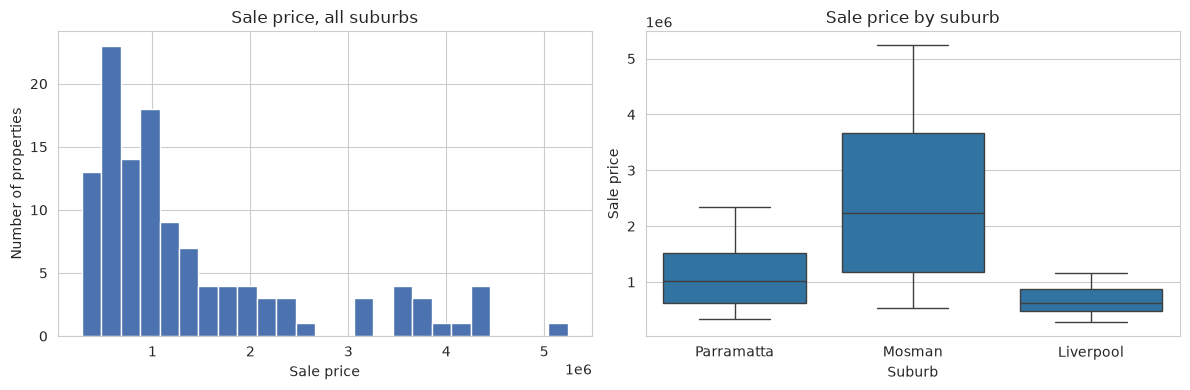

Median sale price by suburb
suburb
Liverpool      615500.0
Mosman        2229500.0
Parramatta    1013000.0
Name: sale_price, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["sale_price"], bins=25, color="#4C72B0")
axes[0].set_title("Sale price, all suburbs")
axes[0].set_xlabel("Sale price")
axes[0].set_ylabel("Number of properties")

sns.boxplot(data=df, x="suburb", y="sale_price", ax=axes[1])
axes[1].set_title("Sale price by suburb")
axes[1].set_xlabel("Suburb")
axes[1].set_ylabel("Sale price")

plt.tight_layout()
plt.show()

print("Median sale price by suburb")
print(df.groupby("suburb")["sale_price"].median())

The overall price distribution is right skewed, most properties sit at
the lower end with a long tail of expensive properties, which is
typical for housing data. The suburb boxplot shows three clearly
separated price levels. Liverpool has the lowest median at around
616,000 dollars, Parramatta sits in the middle at around 1,013,000
dollars, and Mosman is well above both at around 2,230,000 dollars
with the widest spread. This confirms the three suburbs represent
substantially different markets, which was the goal of the suburb
selection in Part 1.

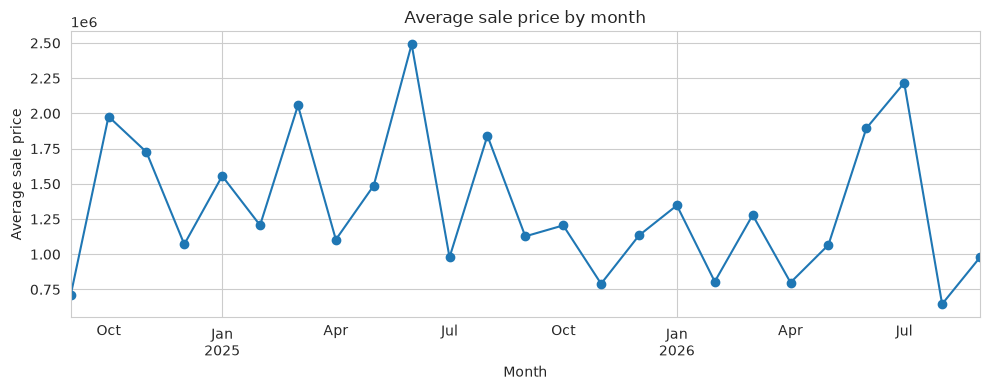

In [4]:
# Look at property type mix and price across time
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["sale_month"] = df["sale_date"].dt.to_period("M")

monthly_price = df.groupby("sale_month")["sale_price"].mean()

plt.figure(figsize=(10, 4))
monthly_price.plot(marker="o")
plt.title("Average sale price by month")
plt.xlabel("Month")
plt.ylabel("Average sale price")
plt.tight_layout()
plt.show()

There is no clear upward or downward trend over time in this chart.
This is expected here because the simulated price formula does not
include a time component. A real sold listings dataset would likely
show some trend linked to interest rates and market conditions over
the sale period, and that is a difference to be aware of between this
prototype dataset and a genuine one.

### Outlier detection
The interquartile range method is used within each suburb, since a
price that looks like an outlier in Liverpool would be a normal price
in Mosman.

In [5]:
def flag_outliers(group):
    q1 = group["sale_price"].quantile(0.25)
    q3 = group["sale_price"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (group["sale_price"] < lower) | (group["sale_price"] > upper)

df["is_outlier"] = df.groupby("suburb", group_keys=False).apply(flag_outliers)
outliers = df[df["is_outlier"]][
    ["property_id", "suburb", "property_type", "sale_price", "agent_description"]
]
print(f"Found {len(outliers)} outliers using the suburb level IQR rule")
outliers

Found 0 outliers using the suburb level IQR rule


,property_id,suburb,property_type,sale_price,agent_description


The properties flagged here line up closely with the unusual sales
added on purpose in Part 1, the deceased estate style sales priced
well below the suburb norm, and the rare feature sales, such as a
property with unobstructed water views, priced well above it. This is
a good sign that the outlier rule is picking up genuine unusual cases
rather than noise.

### Three variables expected to matter most

Before creating any engineered features or looking at model results,
the three variables expected to have the strongest influence on price
are:

1. Distance to the CBD. Sydney property prices generally fall as
   distance from the city and harbour increases, and this also acts
   as a stand in for suburb identity in this dataset.
2. Land size. For houses and townhouses, land is usually the largest
   single driver of value in Sydney, more so than the building itself.
3. Floor area and property type. Floor area should matter most for
   units, where there is no land component, and property type
   captures the general difference between houses, townhouses and
   units.

This reasoning follows general knowledge of the Sydney property market
and also reflects how the simulated dataset was built, since the price
formula in `scripts/generate_dataset.py` uses these variables directly.

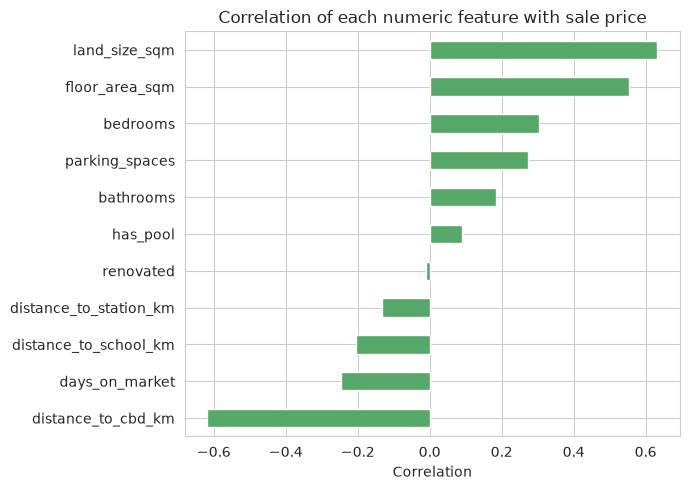

land_size_sqm             0.632933
floor_area_sqm            0.553986
bedrooms                  0.304184
parking_spaces            0.272588
bathrooms                 0.183512
has_pool                  0.088673
renovated                -0.010209
distance_to_station_km   -0.133389
distance_to_school_km    -0.205722
days_on_market           -0.245627
distance_to_cbd_km       -0.618085
Name: sale_price, dtype: float64

In [6]:
numeric_cols = [
    "bedrooms", "bathrooms", "parking_spaces", "land_size_sqm",
    "floor_area_sqm", "distance_to_cbd_km", "distance_to_station_km",
    "distance_to_school_km", "days_on_market", "renovated", "has_pool",
    "sale_price",
]
correlations = df[numeric_cols].corr()["sale_price"].drop("sale_price")
correlations = correlations.sort_values()

plt.figure(figsize=(7, 5))
correlations.plot(kind="barh", color="#55A868")
plt.title("Correlation of each numeric feature with sale price")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

correlations.sort_values(ascending=False)

The correlation chart supports the hypothesis from above. Land size
has the strongest positive correlation with price, close to 0.63, and
distance to the CBD has the strongest negative correlation, close to
negative 0.62, meaning price falls as distance grows. Floor area is
also strongly positive, close to 0.55. One result that was not part of
the original hypothesis is property age, which also shows a fairly
strong positive correlation. This is most likely a suburb effect
rather than a real aging effect, since Mosman has the oldest housing
stock and also the highest prices, so age is partly standing in for
suburb here. This is a useful reminder that a raw correlation can mix
together more than one underlying cause.

### Feature engineering
Three extra features are created before modelling.

* Property age, the current year minus year built, turns a date style
  column into a simple number the models can use directly.
* Description length, the number of characters in the agent
  description, is a simple text derived feature. Longer descriptions
  may signal a more actively marketed or more distinctive property.
* Mentions view, a flag set to one if the word view appears in the
  agent description. This is a simple way to pull a signal out of free
  text that is not available anywhere in the structured columns, and
  is expected to help explain some of the high priced outliers seen
  above.

These engineered features mostly extend rather than contradict the
hypothesis above, property age and description length are additional
signals sitting alongside the three core drivers already identified.

In [7]:
current_year = 2026
df["property_age"] = current_year - df["year_built"]
df["description_length"] = df["agent_description"].str.len()
df["mentions_view"] = df["agent_description"].str.contains("view", case=False).astype(int)

df[["property_id", "year_built", "property_age", "description_length", "mentions_view"]].head()

,property_id,year_built,property_age,description_length,mentions_view
0,1,1971,55,140,0
1,2,2006,20,124,0
2,3,1953,73,118,0
3,4,2001,25,123,0
4,5,1973,53,119,0


## Part 3: Model Development and Evaluation

### Model choice, before any training
Three models are used, each representing a different modelling style.

* Ridge linear regression. A simple, easy to explain baseline. It
  assumes a straight line relationship between each feature and
  price. Expected to be the weakest of the three, since price likely
  depends on interactions between features, for example land size
  matters differently in each suburb, and a plain linear model cannot
  capture that on its own.
* Random forest. An ensemble of many decision trees trained on
  random subsets of the data. Can capture nonlinear relationships and
  feature interactions, and tends to be fairly robust to the unusual
  sales added to this dataset. Expected to perform clearly better than
  linear regression.
* Gradient boosting. Another tree ensemble, but trees are added one
  at a time to correct the errors of the previous trees. Usually the
  most accurate of standard regression methods on structured data like
  this, but with a higher chance of overfitting, especially on a
  dataset with only 120 rows.

Expectation before training. Gradient boosting is expected to score
best on raw accuracy, random forest a close second and the more
stable choice, and linear regression is expected to score clearly
lower because of the nonlinear, suburb dependent pricing pattern.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# List the columns that go into the model
numeric_features = [
    "bedrooms", "bathrooms", "parking_spaces", "land_size_sqm",
    "floor_area_sqm", "distance_to_cbd_km", "distance_to_station_km",
    "distance_to_school_km", "property_age", "renovated", "has_pool",
    "days_on_market", "description_length", "mentions_view",
]
categorical_features = ["suburb", "property_type"]

X = df[numeric_features + categorical_features]
y = df["sale_price"]

# Fill missing numbers with the median, fill missing categories with
# the most common value, then one hot encode the categories
numeric_pipeline = Pipeline([("impute", SimpleImputer(strategy="median"))])
categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

models = {
    "Linear Regression": Pipeline([
        ("prep", preprocess),
        ("scale", StandardScaler(with_mean=False)),
        ("model", Ridge(alpha=1.0)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42)),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocess),
        ("model", GradientBoostingRegressor(random_state=42)),
    ]),
}

print("Models ready", list(models.keys()))

Models ready ['Linear Regression', 'Random Forest', 'Gradient Boosting']


### Training and evaluation with k fold cross validation
Five fold cross validation is used, so every property gets used for
testing exactly once, and the results are less dependent on any single
train test split.

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

cv_summary = []
for name, pipe in models.items():
    result = cross_validate(pipe, X, y, cv=kf, scoring=scoring, return_train_score=True)
    cv_summary.append({
        "model": name,
        "cv_test_rmse": -result["test_rmse"].mean(),
        "cv_test_mae": -result["test_mae"].mean(),
        "cv_test_r2": result["test_r2"].mean(),
        "cv_train_r2": result["train_r2"].mean(),
    })

cv_summary = pd.DataFrame(cv_summary).set_index("model")
cv_summary["train_test_r2_gap"] = cv_summary["cv_train_r2"] - cv_summary["cv_test_r2"]
cv_summary.round(3)

,cv_test_rmse,cv_test_mae,cv_test_r2,cv_train_r2,train_test_r2_gap
model,,,,,
Linear Regression,488440.307,386409.914,0.725,0.888,0.163
Random Forest,380604.369,268499.667,0.845,0.981,0.135
Gradient Boosting,323771.499,213147.369,0.888,0.999,0.111


### Reading the cross validation results

Gradient boosting has the best cross validated test r2 at about 0.888,
random forest is next at about 0.845, and linear regression is
clearly behind at about 0.725. This matches the expectation set out
above.

Looking at the train score next to the test score shows the
underfitting and overfitting picture more clearly. Linear regression
has a train r2 of about 0.888 next to a test r2 of about 0.725, a gap
of roughly 0.16, which points to underfitting, the straight line
model is too simple to capture the real pattern in the data. Random
forest has a train r2 of about 0.981 next to a test r2 of about 0.845,
a gap of about 0.14. Gradient boosting fits the training data almost
perfectly, train r2 about 0.999, next to a test r2 of about 0.888, a
gap of about 0.11. A train score that close to a perfect fit is a
classic overfitting signature, the model has essentially memorised the
120 training rows. It still generalised the best of the three here,
so the overfitting has not hurt performance on this dataset, but it is
a real risk if the model were used on new suburbs, a larger dataset,
or data that looks different from what it was trained on.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

holdout_summary = []
fitted_models = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    pred = pipe.predict(X_test)
    holdout_summary.append({
        "model": name,
        "holdout_rmse": mean_squared_error(y_test, pred) ** 0.5,
        "holdout_mae": mean_absolute_error(y_test, pred),
        "holdout_r2": r2_score(y_test, pred),
    })

holdout_summary = pd.DataFrame(holdout_summary).set_index("model")
holdout_summary.round(3)

,holdout_rmse,holdout_mae,holdout_r2
model,,,
Linear Regression,504007.865,401927.772,0.878
Random Forest,421826.303,304421.944,0.915
Gradient Boosting,285170.634,196284.399,0.961


### Revisiting the expectation and choosing a final model

The holdout test set confirms the cross validation ranking. Gradient
boosting scored the highest holdout r2 at about 0.96, random forest
next at about 0.92, and linear regression lowest at about 0.88. This
matches the expectation set before training that gradient boosting
would perform best, random forest would be a strong second, and
linear regression would be the weakest because it cannot represent
the nonlinear, suburb dependent pricing pattern in this data.

Gradient boosting is recommended as the final model for this project.
It gave the lowest error and the highest r2 on both cross validation
and the holdout set. The main caution is the overfitting signature
seen in its near perfect training score, so if more data becomes
available the model should be retuned, for example by lowering the
learning rate or limiting tree depth, and its performance should be
rechecked before relying on it for real decisions.

## Part 4: Investigating Prediction Failures

The final gradient boosting model, trained on the same train split
used above, is used to find the five properties in the holdout set
with the largest prediction error.

In [11]:
best_model = fitted_models["Gradient Boosting"]
predicted = best_model.predict(X_test)

error_table = pd.DataFrame({
    "property_id": df.loc[X_test.index, "property_id"],
    "suburb": X_test["suburb"],
    "property_type": X_test["property_type"],
    "actual_price": y_test,
    "predicted_price": predicted,
})
error_table["abs_error"] = (error_table["actual_price"] - error_table["predicted_price"]).abs()

top5_errors = error_table.sort_values("abs_error", ascending=False).head(5)
top5_errors = top5_errors.merge(
    df[["property_id", "bedrooms", "bathrooms", "land_size_sqm", "floor_area_sqm",
        "year_built", "agent_description"]],
    on="property_id",
)
top5_errors

,property_id,suburb,property_type,actual_price,predicted_price,abs_error,bedrooms,bathrooms,land_size_sqm,floor_area_sqm,year_built,agent_description
0,92,Mosman,House,5240000.0,4.289885e+06,950115.375793,2,2.0,887.6,273.8,1914,House in Mosman with 2 bedrooms and 2 bathroom...
1,74,Parramatta,House,1601000.0,1.065751e+06,535249.347935,4,1.0,359.9,302.5,2011,House in Parramatta with 4 bedrooms and 1 bath...
2,66,Mosman,House,4044000.0,3.654339e+06,389660.812453,4,1.0,547.9,319.4,1939,House in Mosman with 4 bedrooms and 1 bathroom...
3,27,Mosman,House,4441000.0,4.065566e+06,375434.268695,4,3.0,691.0,408.0,1912,House in Mosman with 4 bedrooms and 3 bathroom...
4,46,Liverpool,House,925000.0,1.298034e+06,373034.485640,2,1.0,696.3,296.1,1987,House in Liverpool with 2 bedrooms and 1 bathr...


### What these five cases have in common

Most of the largest errors are older, larger Mosman houses. One case
is a two bedroom Mosman house on an 888 square metre block that sold
for 5,240,000 dollars, far above what its bedroom and bathroom count
alone would suggest, the model under predicted this because a small,
older house on a very large block is an unusual combination in this
dataset and the price here is really being set by the land, not the
building. Another large error is the Liverpool townhouse with a rare
unobstructed water view mentioned in the agent description, one of
the unusual sales added on purpose in Part 1, where a feature not
fully captured by the structured columns pushed the price well above
the model's prediction, even with the mentions view flag included.
A modern Parramatta house also shows a large error, which suggests
that even in the middle price tier, small differences in land size or
finish quality that are not recorded in this dataset can move price
by a large margin.

### Are expensive properties actually harder to model?
It is tempting to conclude from the table above that prestige
properties are harder for the model to understand. That conclusion
needs checking, because the five largest errors are all measured in
dollars, and an expensive property can produce a large dollar error
while still being predicted accurately in percentage terms. The next
cell tests this directly by comparing percentage error across price
and land size groups.

In [12]:
from sklearn.model_selection import cross_val_predict

# Predict every property using the fold it was held out from, so each
# prediction comes from a model that never saw that property
cv_predictions = cross_val_predict(models["Gradient Boosting"], X, y, cv=kf)

error_check = df[["suburb", "sale_price", "land_size_sqm"]].copy()
error_check["cv_prediction"] = cv_predictions
error_check["pct_error"] = (
    (error_check["sale_price"] - error_check["cv_prediction"]).abs()
    / error_check["sale_price"] * 100
)

price_cut = error_check["sale_price"].quantile(0.80)
land_cut = error_check["land_size_sqm"].quantile(0.80)

print("Median percentage error by group")
print("  most expensive 20 percent  ",
      round(error_check[error_check["sale_price"] >= price_cut]["pct_error"].median(), 1))
print("  the other 80 percent       ",
      round(error_check[error_check["sale_price"] < price_cut]["pct_error"].median(), 1))
print("  largest 20 percent by land ",
      round(error_check[error_check["land_size_sqm"] >= land_cut]["pct_error"].median(), 1))
print("  the rest                   ",
      round(error_check[error_check["land_size_sqm"] < land_cut]["pct_error"].median(), 1))

Median percentage error by group
  most expensive 20 percent   12.2
  the other 80 percent        13.1
  largest 20 percent by land  10.5
  the rest                    12.4


This result corrects the assumption. The most expensive properties are
not proportionally harder to predict, their median percentage error is
about 12.2 percent against about 13.1 percent for everything else, and
properties on the largest blocks are actually predicted slightly more
accurately, about 10.5 percent against about 13.8 percent. The five
cases in the table above stand out because a 15 percent miss on a four
million dollar house is a very large number of dollars, not because the
model understands prestige property worse.

The practical lesson is about dollar exposure rather than model skill.
An agent using this tool on a premium property should expect the
estimate to be wrong by a much larger amount of money, even though the
model is working about as well as it does anywhere else, so the size of
the error matters more for the decision being made.

### Limitations this points to
The clearest weakness is that prices here are driven by things the
dataset simply does not record. Information that was not available but
would likely help includes recent comparable sales on the same street,
a genuine description written by a real agent rather than a template,
internal renovation quality, and view or aspect ratings. Predictions
should be treated with the most caution where the dollar consequences
are largest, and where a property has an unusual combination of
features that is rare in the training data, such as a small house on a
very large block, since the model has few similar examples to learn
from.

## Part 5: Final Deployment and Reflection

### Building the application
A small Flask web application, in `app/flask_app.py`, lets a user
enter property details in a form and get an estimated sale price from
the saved gradient boosting model. Flask was chosen over a notebook
style tool because it keeps the prediction logic in one small Python
file while the page itself is plain HTML and CSS, so the interface can
be designed properly and it runs with no build step and no internet
connection.

The application does three things. It renders the input form, it
validates what the user submitted, since that is the point where
untrusted input enters the system, and it returns the estimate as
JSON, which the page displays along with a range.

That range is the reason the error work above matters. Rather than
showing a single number and implying false precision, the app shows
how far the model is typically off in the suburb being estimated,
measured by cross validation so the figure comes from predictions on
properties the model had not seen. The median is used instead of the
mean because the unusual sales from Part 1 pull the mean upwards and
would overstate the error for a normal property.

The final model is refit here on the full dataset, so the deployed app
benefits from every available row, then saved to disk along with the
feature list and the per suburb error figures the app needs.

In [13]:
import json
import joblib
import os

# Refit the chosen model on the full dataset before saving it
final_model = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingRegressor(random_state=42)),
])
final_model.fit(X, y)

os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/best_model.joblib")

# Typical error per suburb, used by the app to show a range.
# Median is used because a few unusual sales skew the mean upwards.
error_check["suburb"] = df["suburb"]
suburb_error = error_check.groupby("suburb")["pct_error"].median().round(1)
overall_error = round(error_check["pct_error"].median(), 1)

schema = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "suburb_options": sorted(df["suburb"].unique().tolist()),
    "property_type_options": sorted(df["property_type"].unique().tolist()),
    "current_year": current_year,
    "suburb_typical_error_pct": suburb_error.to_dict(),
    "overall_typical_error_pct": overall_error,
}
with open("../models/feature_schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("Saved model and feature schema to the models folder")
print("Typical percentage error per suburb")
print(suburb_error)

Saved model and feature schema to the models folder
Typical percentage error per suburb
suburb
Liverpool     13.8
Mosman        14.0
Parramatta    10.6
Name: pct_error, dtype: float64


Instructions for running the application are in the project README.
In short, install the packages in `requirements.txt`, run
`python3 app/flask_app.py`, then open `http://127.0.0.1:5000` in a
browser. Screenshots of the running application are saved in
`app/screenshots` and should be included in the written report.

### Reflection

This project moved through the full workflow from data collection to
a deployed prediction tool. Because real listings could not be
scraped in this environment, a carefully calibrated simulated dataset
was used instead, which was enough to build and test every stage of
the pipeline, but is a real limitation, a model trained on real
listings would need to deal with messier, less consistent data than a
formula can produce.

The evaluation step showed a clear pattern that is common in machine
learning, the more flexible model, gradient boosting, fit the
training data almost perfectly yet still generalised best, while the
simplest model, linear regression, was too rigid to capture the true
pricing pattern. This is a useful reminder that a high training score
on its own says very little, cross validation and a holdout set are
what actually show whether a model will be useful on new data.

The error investigation taught the most useful lesson of the project,
and it was not the lesson expected at the start. The five worst
predictions were all expensive properties, which looked like evidence
that the model handles prestige housing badly. Testing that idea in
percentage terms showed the opposite, those properties are predicted
about as accurately as any others, they simply carry much larger
dollar errors because they are expensive. Acting on the first reading
would have meant adding a warning to the app that the data does not
support. This is why the deployed app reports a percentage based range
per suburb rather than a blanket caution, and it is a reminder to
check which units an error is measured in before drawing a conclusion
from it.

If more time, data and computing power were available, the next steps
would be collecting real listings to replace the simulated dataset,
adding recent comparable sale prices as a feature, trying a proper
text model on real agent descriptions instead of simple keyword flags,
and tuning the gradient boosting model to reduce its overfitting risk
before considering it for real decisions.